# 🚚 AGV 倉庫路線規劃系統 (Ant Colony Optimization)

copy ver3. 拆開距離最佳化，BFS+曼哈頓+ACO 是看看 energy ，訂單固定指定，迭帶可以調 `def plan_agv_routes_with_aco_allocation`+分 batch 跑+能量+權重

本系統使用螞蟻演算法(ACO)為多輛AGV在倉庫環境中規劃最優路線，包含：
- 倉庫佈局載入與座標對齊
- BFS + 曼哈頓路徑規劃與碰撞避免
- 螞蟻演算法優化
- 完整的視覺化展示
- Flexsim匯出功能

```
📦 任務分配問題
    ↓
🐜 ACO 最佳化分配
    ├─ 計算任務間實際距離
    ├─ 考慮AGV負載平衡  
    ├─ 最小化總完成時間
    └─ 輸出：每台AGV的任務列表
    ↓
🔍 BFS 詳細路徑規劃
    ├─ 為每台AGV規劃實際可走路徑
    ├─ 避開障礙物和衝突
    └─ 輸出：具體的移動步驟

## 📦 導入必要套件

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from collections import defaultdict, deque
from typing import List, Tuple, Dict, Optional
import math
import random
import heapq
import json

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("📦 套件載入完成")

📦 套件載入完成


## 能量計算

In [73]:
# 🔋 能量計算系統
print("🔋 載入能量計算系統...")

# 能量參數定義
ENERGY_PARAMS = {
    "v": 1.39,                    # m/s ≈ 5 km/h
    "m_vehicle": 110.0,           # kg
    "m_item": 10.0,               # kg/件
    "mu": 0.02,                   # 滾動阻力係數
    "g": 9.81,                    # m/s^2
    "M_turn": 10.0,               # J/rad
    "theta_per_turn": math.pi/2,  # 90°
    "lift_h": 0.5,                # m
    "lift_eta": 0.7,              # 效率
    "P_idle": 100.0,              # W
    "T_idle_per_pick": 2.0,       # s/件
}

def compute_agv_energy(path_coords, pickup_positions, params, cell_m=1.0):
    """
    計算AGV路徑的能量消耗
    
    參數:
    - path_coords: AGV完整路徑座標列表 [(x1,y1), (x2,y2), ...]
    - pickup_positions: 取貨位置列表 [(x1,y1), (x2,y2), ...]
    - params: 能量參數字典
    - cell_m: 每格距離（公尺）
    
    返回: 能量統計字典
    """
    if len(path_coords) < 2:
        return {"E_total_J": 0.0, "Ct_m": 0.0}
    
    # 提取參數
    v = params["v"]; m0 = params["m_vehicle"]; m1 = params["m_item"]
    mu = params["mu"]; g = params["g"]
    M_turn = params["M_turn"]; theta = params["theta_per_turn"]
    h = params["lift_h"]; eta = params["lift_eta"]
    P_idle = params["P_idle"]; T_idle = params["T_idle_per_pick"]
    
    # 計算移動距離和轉向
    total_distance = 0.0
    turns = 0
    prev_direction = None
    
    # 追踪累積取貨數量
    pickup_count = 0
    
    for i in range(len(path_coords) - 1):
        curr_pos = path_coords[i]
        next_pos = path_coords[i + 1]
        
        # 檢查是否到達取貨點
        if curr_pos in pickup_positions:
            pickup_count += 1
        
        # 計算移動距離（曼哈頓距離）
        step_distance = abs(next_pos[0] - curr_pos[0]) + abs(next_pos[1] - curr_pos[1])
        total_distance += step_distance
        
        # 計算轉向
        if step_distance > 0:  # 有移動才計算方向
            direction = (
                1 if next_pos[0] > curr_pos[0] else -1 if next_pos[0] < curr_pos[0] else 0,
                1 if next_pos[1] > curr_pos[1] else -1 if next_pos[1] < curr_pos[1] else 0
            )
            
            if prev_direction is not None and direction != prev_direction:
                turns += 1
            
            prev_direction = direction
    
    # 能量計算
    Ct_m = total_distance * cell_m
    
    # 滾動阻力（考慮負載變化）
    avg_mass = m0 + m1 * (pickup_count / 2)  # 平均負載
    E_roll = mu * avg_mass * g * Ct_m
    
    # 加速能量（每段移動）
    move_count = sum(1 for i in range(len(path_coords)-1) 
                    if abs(path_coords[i+1][0] - path_coords[i][0]) + 
                       abs(path_coords[i+1][1] - path_coords[i][1]) > 0)
    E_accel = 0.5 * avg_mass * (v**2) * move_count
    
    # 轉向能量
    E_rot = turns * M_turn * theta
    
    # 升降能量
    n_picks = len(pickup_positions)
    E_lift = n_picks * (m1 * g * h / eta)
    
    # 待機能量
    E_idle = P_idle * T_idle * n_picks
    
    # 總能量
    E_total = E_roll + E_accel + E_rot + E_lift + E_idle
    
    return {
        "E_total_J": float(E_total),
        "Ct_m": float(Ct_m),
        "E_roll_J": float(E_roll),
        "E_accel_J": float(E_accel),
        "E_rot_J": float(E_rot),
        "E_lift_J": float(E_lift),
        "E_idle_J": float(E_idle),
        "turns": int(turns),
        "pickup_count": int(n_picks)
    }

print("🔋 能量計算系統載入完成")

🔋 載入能量計算系統...
🔋 能量計算系統載入完成


## 🏢 倉庫類別定義

In [74]:
class Warehouse:
    """
    倉庫類別：管理倉庫佈局、儲位資訊和路徑規劃
    """
    def __init__(self, layout_df: pd.DataFrame, storage_map: Dict, 
                 item_to_locations: Dict, storage_grid: np.ndarray, map_mask: np.ndarray):
        self.layout_df = layout_df
        self.storage_map = storage_map  # (x,y) -> item_name
        self.item_to_locations = item_to_locations  # item_name -> [(x,y), ...]
        self.storage_grid = storage_grid
        self.map_mask = map_mask  # 1=可行走, 0=障礙物
        self.rows, self.cols = map_mask.shape
    
    def is_walkable(self, x: int, y: int) -> bool:
        """檢查座標是否可行走"""
        return (0 <= x < self.cols and 0 <= y < self.rows and 
                self.map_mask[y, x] == 1)
    
    def get_neighbors(self, x: int, y: int) -> List[Tuple[int, int]]:
        """獲取可行走的相鄰座標"""
        neighbors = []
        for dx, dy in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.is_walkable(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors
    
    def bfs_path(self, start: Tuple[int, int], goal: Tuple[int, int], 
                 occupied_positions: set = None) -> Optional[List[Tuple[int, int]]]:
        """使用BFS尋找路徑，避開已佔用位置"""
        if occupied_positions is None:
            occupied_positions = set()
        
        if not self.is_walkable(start[0], start[1]) or not self.is_walkable(goal[0], goal[1]):
            return None
        
        if start in occupied_positions or goal in occupied_positions:
            return None
            
        queue = deque([(start, [start])])
        visited = {start}
        
        while queue:
            (x, y), path = queue.popleft()
            
            if (x, y) == goal:
                return path
            
            for next_x, next_y in self.get_neighbors(x, y):
                if (next_x, next_y) not in visited and (next_x, next_y) not in occupied_positions:
                    visited.add((next_x, next_y))
                    queue.append(((next_x, next_y), path + [(next_x, next_y)]))
        
        return None

print("🏢 倉庫類別定義完成")

🏢 倉庫類別定義完成


## 📂 倉庫佈局載入函數

In [75]:
def load_warehouse_from_csv(csv_file='warehouse.csv') -> Warehouse:
    """
    從CSV檔案載入倉庫佈局並建立Warehouse物件
    - CSV中 0=通道, 數字=貨品編號
    - MapMask中 1=可行走, 0=障礙物
    """
    print(f"📂 正在載入倉庫佈局: {csv_file}")
    
    # 載入CSV佈局
    df_layout = pd.read_csv(csv_file, header=None)
    print(f"   CSV佈局形狀: {df_layout.shape}")
    
    # 載入MapMask
    map_mask = pd.read_csv('MapMask_preview.csv', header=None).values
    print(f"   MapMask形狀: {map_mask.shape}")
    
    # 驗證形狀一致性
    if df_layout.shape != map_mask.shape:
        raise ValueError(f"形狀不匹配: CSV {df_layout.shape} vs MapMask {map_mask.shape}")
    
    # 建立儲位對應表
    storage_map = {}
    item_to_locations = defaultdict(list)
    storage_grid = np.zeros_like(df_layout, dtype=int)
    
    cargo_count = 0
    walkway_count = 0
    
    # 使用正確偏移量 (0, 0)
    offset_x, offset_y = 0, 0
    
    for y in range(df_layout.shape[0]):
        for x in range(df_layout.shape[1]):
            val = df_layout.iat[y, x]
            if val == 0:
                walkway_count += 1
            else:
                # 貨品位置
                item_name = str(int(val))
                storage_map[(x, y)] = item_name
                item_to_locations[item_name].append((x, y))
                storage_grid[y, x] = 1
                cargo_count += 1
    
    print(f"   ✅ 載入完成: {len(item_to_locations)} 種貨品, {cargo_count} 個儲位, {walkway_count} 個通道")
    print(f"   ✅ 使用座標偏移量: ({offset_x}, {offset_y})")
    
    return Warehouse(df_layout, storage_map, item_to_locations, storage_grid, map_mask)

print("📂 倉庫載入函數定義完成")

📂 倉庫載入函數定義完成


## 🎯 智慧取貨位置生成

In [76]:
def find_accessible_position(cargo_pos: Tuple[int, int], map_mask: np.ndarray) -> Tuple[int, int]:
    """
    找到貨品位置旁邊的可行走位置
    AGV無法直接到達貨品位置（障礙物），需要到相鄰的可行走位置
    """
    x, y = cargo_pos
    
    # 檢查四個相鄰位置（上下左右）
    directions = [(0, -1), (0, 1), (-1, 0), (1, 0)]  # 上、下、左、右
    
    for dx, dy in directions:
        new_x, new_y = x + dx, y + dy
        if (0 <= new_x < map_mask.shape[1] and 
            0 <= new_y < map_mask.shape[0] and
            map_mask[new_y, new_x] == 1):  # 可行走區域
            return (new_x, new_y)
    
    # 如果四個相鄰位置都不可行走，檢查對角線位置
    diagonals = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    for dx, dy in diagonals:
        new_x, new_y = x + dx, y + dy
        if (0 <= new_x < map_mask.shape[1] and 
            0 <= new_y < map_mask.shape[0] and
            map_mask[new_y, new_x] == 1):
            return (new_x, new_y)
    
    raise ValueError(f"找不到貨品位置{cargo_pos}的可行走相鄰位置")

def generate_order_locations(order: List[str],
                           item_to_locations: Dict[str, List[Tuple[int,int]]],
                           map_mask: np.ndarray,
                           start_point: Tuple[int,int]=(15,0)) -> List[Tuple[int,int]]:
    """
    為訂單生成AGV可到達的取貨位置
    選擇距離起點最近且未被使用的位置
    """
    used_coords = set()
    coords = []
    used_by_item = defaultdict(set)

    for item in order:
        if item not in item_to_locations:
            raise ValueError(f"品項 {item} 不存在於倉庫中")
            
        cargo_candidates = [loc for loc in item_to_locations[item]
                           if loc not in used_by_item[item]]
        
        if not cargo_candidates:
            raise ValueError(f"品項 {item} 缺可用儲位")
        
        # 為每個候選貨品位置找到可行走的相鄰位置
        accessible_candidates = []
        for cargo_pos in cargo_candidates:
            try:
                accessible_pos = find_accessible_position(cargo_pos, map_mask)
                if accessible_pos not in used_coords:
                    accessible_candidates.append((accessible_pos, cargo_pos))
            except ValueError:
                continue  # 這個貨品位置無法到達，跳過
        
        if not accessible_candidates:
            raise ValueError(f"品項 {item} 沒有可到達的儲位")
        
        # 選擇距離起點最近的可行走位置
        chosen_accessible, chosen_cargo = min(accessible_candidates,
                                            key=lambda x: abs(x[0][0]-start_point[0]) + 
                                                        abs(x[0][1]-start_point[1]))
        
        coords.append(chosen_accessible)
        used_coords.add(chosen_accessible)
        used_by_item[item].add(chosen_cargo)
    
    return coords

print("🎯 智慧取貨位置生成函數定義完成")

🎯 智慧取貨位置生成函數定義完成


## 🐜 螞蟻演算法 ACO 優化

In [77]:
class SimpleACO:
    """
    簡化版螞蟻演算法用於解決TSP問題
    優化AGV訪問多個取貨點的順序
    """
    def __init__(self, coords: List[Tuple[int,int]], start=(15,0),
                 n_ants=10, n_iter=100, alpha=1, beta=5, evaporation=0.5, q=100):
        self.start = start
        self.coords = coords  # 不包含起點
        self.n = len(coords)
        self.n_ants = n_ants
        self.n_iter = n_iter
        self.alpha = alpha  # 費洛蒙重要性
        self.beta = beta    # 距離重要性
        self.evaporation = evaporation
        self.q = q
        
        # 計算距離矩陣（包含起點）
        all_points = [start] + coords
        self.distances = np.zeros((len(all_points), len(all_points)))
        for i, p1 in enumerate(all_points):
            for j, p2 in enumerate(all_points):
                # 改為曼哈頓距離
                self.distances[i][j] = abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])
        
        # 初始化費洛蒙矩陣
        self.pheromones = np.ones((len(all_points), len(all_points)))
        
        self.best_path = None
        self.best_distance = float('inf')
    
    def solve(self) -> Tuple[List[int], float]:
        """執行螞蟻演算法求解"""
        for iteration in range(self.n_iter):
            # 所有螞蟻構建解
            all_paths = []
            all_distances = []
            
            for ant in range(self.n_ants):
                path, distance = self._construct_solution()
                all_paths.append(path)
                all_distances.append(distance)
                
                # 更新最佳解
                if distance < self.best_distance:
                    self.best_distance = distance
                    self.best_path = path.copy()
            
            # 更新費洛蒙
            self._update_pheromones(all_paths, all_distances)
        
        return self.best_path, self.best_distance
    
    def _construct_solution(self) -> Tuple[List[int], float]:
        """單隻螞蟻構建解"""
        current = 0  # 從起點開始
        unvisited = set(range(1, self.n + 1))  # 待訪問的點（不包含起點）
        path = [current]
        total_distance = 0
        
        while unvisited:
            next_city = self._select_next_city(current, unvisited)
            path.append(next_city)
            total_distance += self.distances[current][next_city]
            current = next_city
            unvisited.remove(next_city)
        
        # 返回起點
        path.append(0)
        total_distance += self.distances[current][0]
        
        return path, total_distance
    
    def _select_next_city(self, current: int, unvisited: set) -> int:
        """選擇下一個城市"""
        probabilities = []
        
        for city in unvisited:
            pheromone = self.pheromones[current][city] ** self.alpha
            visibility = (1.0 / max(self.distances[current][city], 0.001)) ** self.beta
            probabilities.append(pheromone * visibility)
        
        # 轉換為機率分布
        total = sum(probabilities)
        if total == 0:
            return random.choice(list(unvisited))
        
        probabilities = [p / total for p in probabilities]
        
        # 輪盤選擇
        r = random.random()
        cumulative = 0
        cities = list(unvisited)
        
        for i, prob in enumerate(probabilities):
            cumulative += prob
            if r <= cumulative:
                return cities[i]
        
        return cities[-1]
    
    def _update_pheromones(self, all_paths: List[List[int]], all_distances: List[float]):
        """更新費洛蒙"""
        # 蒸發
        self.pheromones *= (1 - self.evaporation)
        
        # 添加新費洛蒙
        for path, distance in zip(all_paths, all_distances):
            pheromone_deposit = self.q / distance
            for i in range(len(path) - 1):
                from_city = path[i]
                to_city = path[i + 1]
                self.pheromones[from_city][to_city] += pheromone_deposit
                self.pheromones[to_city][from_city] += pheromone_deposit

print("🐜 螞蟻演算法類別定義完成")

🐜 螞蟻演算法類別定義完成


## 🎯 ACO 動態任務分配系統

In [78]:
class EnhancedACOTaskAllocator:
    """
    增強版螞蟻演算法任務分配系統
    整合能量計算和多目標優化 (能量 + 距離)
    """
    def __init__(self, num_agvs=3, n_ants=20, n_iter=100, alpha=1.0, beta=2.0, 
                 rho=0.1, max_items_per_trip=5, gamma=0.5, delta=0.5, energy_params=None):
        self.num_agvs = num_agvs
        self.n_ants = n_ants
        self.n_iter = n_iter
        self.alpha = alpha  # 費洛蒙重要性
        self.beta = beta    # 啟發式資訊重要性
        self.rho = rho      # 費洛蒙揮發率
        self.max_items_per_trip = max_items_per_trip
        
        # 🔋 新增：多目標權重
        self.gamma = gamma  # 能量權重
        self.delta = delta  # 距離權重
        self.energy_params = energy_params or ENERGY_PARAMS
        
        print(f"🔋 增強版ACO啟動: γ(能量)={gamma}, δ(距離)={delta}")
        
    def allocate_tasks(self, all_task_items: List[str], warehouse: Warehouse, 
                      depot: Tuple[int, int] = (15, 0)) -> Dict:
        """
        使用能量感知ACO分配任務
        """
        print(f"🎯 開始能量感知ACO分配 {len(all_task_items)} 個任務給 {self.num_agvs} 台AGV...")
        
        # 生成任務位置
        task_locations = self._generate_all_task_locations(all_task_items, warehouse, depot)
        print(f"   ✅ 生成了 {len(task_locations)} 個任務取貨位置")
        
        # 計算距離矩陣
        distances = self._calculate_distance_matrix(task_locations, depot)
        
        # 🔋 修改：使用能量感知ACO
        best_allocation = self._run_energy_aware_aco(task_locations, distances, depot, warehouse)
        
        return best_allocation
    
    def _run_energy_aware_aco(self, task_locations: List[Tuple[int, int]], 
                             distances: np.ndarray, depot: Tuple[int, int], warehouse) -> Dict:
        """
        🔋 新增：執行能量感知ACO演算法
        """
        n_tasks = len(task_locations)
        if n_tasks == 0:
            return {f'AGV-{i+1}': [] for i in range(self.num_agvs)}
        
        # 初始化費洛蒙矩陣
        pheromones = np.ones((n_tasks + 1, self.num_agvs))
        
        best_objective = float('inf')  # 🔋 改為目標函數值
        best_allocation = None
        
        print(f"   🔋 執行 {self.n_iter} 次能量感知ACO迭代...")
        
        for iteration in range(self.n_iter):
            ant_allocations = []
            ant_objectives = []  # 🔋 改為目標函數值
            
            for ant in range(self.n_ants):
                allocation = self._construct_allocation_solution(n_tasks, distances, pheromones)
                
                # 🔋 新增：計算多目標函數值
                objective_value = self._calculate_multi_objective(
                    allocation, task_locations, depot, warehouse
                )
                
                ant_allocations.append(allocation)
                ant_objectives.append(objective_value)
                
                # 更新最佳解
                if objective_value < best_objective:
                    best_objective = objective_value
                    best_allocation = allocation.copy()
            
            # 🔋 修改：使用目標函數值更新費洛蒙
            self._update_pheromones_with_objectives(pheromones, ant_allocations, ant_objectives)
            
            if iteration % 20 == 0:
                print(f"      迭代 {iteration}: 最佳目標值 = {best_objective:.2f}")
        
        result = self._format_allocation_result(best_allocation, task_locations, best_objective)
        print(f"   ✅ 能量感知ACO完成! 最佳目標值: {best_objective:.2f}")
        return result
    
    def _calculate_multi_objective(self, allocation: Dict, task_locations: List[Tuple[int, int]], 
                                 depot: Tuple[int, int], warehouse) -> float:
        """
        🔋 新增：計算多目標函數值 Z = γ*E_total + δ*Ct_total
        """
        total_energy = 0.0
        total_distance = 0.0
        
        for agv_id in range(self.num_agvs):
            if not allocation[agv_id]:
                continue
            
            # 構建該AGV的路徑
            agv_task_positions = [task_locations[i-1] for i in allocation[agv_id]]
            path_coords = [depot] + agv_task_positions + [depot]
            
            # 🔋 使用能量計算函數
            energy_stats = compute_agv_energy(
                path_coords, agv_task_positions, self.energy_params, cell_m=1.0
            )
            
            total_energy += energy_stats["E_total_J"]
            total_distance += energy_stats["Ct_m"]
        
        # 🎯 多目標函數：Z = γ*E + δ*Ct
        objective_value = self.gamma * total_energy + self.delta * total_distance
        return objective_value
    
    def _update_pheromones_with_objectives(self, pheromones: np.ndarray, 
                                         allocations: List[Dict], objectives: List[float]):
        """
        🔋 修改：使用目標函數值更新費洛蒙
        """
        # 揮發
        pheromones *= (1 - self.rho)
        
        # 添加新費洛蒙（目標值越小，費洛蒙越多）
        for allocation, objective in zip(allocations, objectives):
            if objective > 0:
                pheromone_deposit = 100.0 / objective  # 反比例關係
                
                for agv_id in range(self.num_agvs):
                    for task in allocation[agv_id]:
                        pheromones[task][agv_id] += pheromone_deposit
    
    # 保留原有的輔助方法
    def _generate_all_task_locations(self, all_items: List[str], 
                                   warehouse: Warehouse, depot: Tuple[int, int]) -> List[Tuple[int, int]]:
        """保留原有邏輯"""
        task_locations = []
        used_positions = set()
        
        for item in all_items:
            if item not in warehouse.item_to_locations:
                print(f"⚠️  警告: 物品 {item} 不存在於倉庫中")
                continue
                
            available_positions = []
            for cargo_pos in warehouse.item_to_locations[item]:
                try:
                    accessible_pos = find_accessible_position(cargo_pos, warehouse.map_mask)
                    if accessible_pos not in used_positions:
                        available_positions.append(accessible_pos)
                except ValueError:
                    continue
            
            if available_positions:
                best_pos = min(available_positions,
                            key=lambda pos: abs(pos[0]-depot[0]) + abs(pos[1]-depot[1]))
                task_locations.append(best_pos)
                used_positions.add(best_pos)
            else:
                print(f"⚠️  警告: 物品 {item} 無可用取貨位置")
        
        return task_locations
    
    def _calculate_distance_matrix(self, task_locations: List[Tuple[int, int]], 
                                depot: Tuple[int, int]) -> np.ndarray:
        """保留原有邏輯"""
        all_locations = [depot] + task_locations
        n = len(all_locations)
        distances = np.zeros((n, n))
        
        for i in range(n):
            for j in range(n):
                if i != j:
                    distances[i][j] = abs(all_locations[i][0] - all_locations[j][0]) + \
                                    abs(all_locations[i][1] - all_locations[j][1])
        return distances
    
    def _construct_allocation_solution(self, n_tasks: int, distances: np.ndarray, 
                                     pheromones: np.ndarray) -> Dict:
        """保留原有邏輯"""
        allocation = {i: [] for i in range(self.num_agvs)}
        unassigned_tasks = list(range(1, n_tasks + 1))
        agv_loads = [0] * self.num_agvs
        
        while unassigned_tasks:
            task = random.choice(unassigned_tasks)
            
            probabilities = []
            for agv_id in range(self.num_agvs):
                if agv_loads[agv_id] >= self.max_items_per_trip:
                    probabilities.append(0.0)
                else:
                    pheromone = pheromones[task][agv_id] ** self.alpha
                    
                    if allocation[agv_id]:
                        last_task = allocation[agv_id][-1]
                        heuristic = (1.0 / max(distances[last_task][task], 0.001)) ** self.beta
                    else:
                        heuristic = (1.0 / max(distances[0][task], 0.001)) ** self.beta
                    
                    load_factor = 1.0 / (1.0 + agv_loads[agv_id])
                    probabilities.append(pheromone * heuristic * load_factor)
            
            total_prob = sum(probabilities)
            if total_prob == 0:
                chosen_agv = min(range(self.num_agvs), key=lambda x: agv_loads[x])
            else:
                probabilities = [p / total_prob for p in probabilities]
                chosen_agv = np.random.choice(self.num_agvs, p=probabilities)
            
            allocation[chosen_agv].append(task)
            agv_loads[chosen_agv] += 1
            unassigned_tasks.remove(task)
        
        return allocation
    
    def _format_allocation_result(self, allocation: Dict, task_locations: List[Tuple[int, int]], 
                                objective_value: float) -> Dict:
        """🔋 修改：格式化結果，包含目標值"""
        result = {
            'agv_tasks': {},
            'task_locations': task_locations,
            'multi_objective_value': objective_value,  # 🔋 改為多目標值
            'allocation_summary': {}
        }
        
        for agv_id in range(self.num_agvs):
            agv_name = f'AGV-{agv_id + 1}'
            task_indices = allocation[agv_id]
            task_positions = [task_locations[i-1] for i in task_indices]
            
            result['agv_tasks'][agv_name] = task_positions
            result['allocation_summary'][agv_name] = {
                'num_tasks': len(task_positions),
                'task_indices': task_indices
            }
        return result

print("🔋 增強版ACO任務分配系統定義完成")

🔋 增強版ACO任務分配系統定義完成


In [79]:
def plan_agv_routes_with_energy_aco(warehouse: Warehouse, all_task_items: List[str], 
                                   num_agvs: int = 3, depot: Tuple[int, int] = (15, 0),
                                   max_items_per_trip: int = 5, 
                                   gamma: float = 0.5, delta: float = 0.5) -> Dict:
    """
    使用能量感知ACO動態分配任務並規劃路徑
    
    🔋 新增參數:
    - gamma: 能量權重 (越大越重視節能)
    - delta: 距離權重 (越大越重視距離)
    """
    
    # 🔧 權重驗證
    if abs(gamma + delta - 1.0) > 1e-6:
        print(f"⚠️  警告: 權重總和 {gamma + delta:.3f} ≠ 1.0，將自動調整")
        total = gamma + delta
        gamma = gamma / total
        delta = delta / total
        print(f"🔧 調整後權重: γ={gamma:.3f}, δ={delta:.3f}")

    results = {
        'agv_paths': {},
        'agv_orders': {},
        'agv_waypoints': {},
        'total_distance': 0,
        'violations': 0,
        'success': True,
        'message': '',
        'multi_objective_value': 0,  # 🔋 改為多目標值
        'task_allocation': {},
        'aco_makespan': 0.0,
        'energy_config': f'γ={gamma}, δ={delta}',  # 🔋 新增配置資訊
        'total_energy': 0.0,  # 🔋 新增總能量
        'agv_energy_details': {}
    }
    
    print(f"🚚 開始能量感知ACO為 {num_agvs} 輛AGV分配 {len(all_task_items)} 個任務...")
    print(f"🔋 能量配置: γ(能量)={gamma}, δ(距離)={delta}")
    
    try:
        # 🔋 修改：使用增強版分配器
        enhanced_allocator = EnhancedACOTaskAllocator(
            num_agvs=num_agvs,
            n_ants=20,
            n_iter=100,
            max_items_per_trip=max_items_per_trip,
            gamma=gamma,      # 🔋 新增
            delta=delta,      # 🔋 新增
            energy_params=ENERGY_PARAMS  # 🔋 新增
        )
        
        allocation_result = enhanced_allocator.allocate_tasks(all_task_items, warehouse, depot)
        results['multi_objective_value'] = allocation_result['multi_objective_value']  # 🔋 修改
        results['task_allocation'] = allocation_result['allocation_summary']
        
        print(f"✅ 能量感知ACO完成，目標值: {allocation_result['multi_objective_value']:.2f}")
        
        # 2. 為每台AGV規劃詳細路徑（保持原有邏輯）
        for agv_name, task_positions in allocation_result['agv_tasks'].items():
            print(f"\n🚛 {agv_name} 分配到 {len(task_positions)} 個任務位置")
            
            path_valid = True
            
            if not task_positions:
                # 空任務AGV
                results['agv_paths'][agv_name] = [depot]
                results['agv_orders'][agv_name] = []
                results['agv_waypoints'][agv_name] = [depot]
                print(f"   ➤ {agv_name}: 無任務分配")
                continue
            
            # 檢查任務數量是否超過5個，需要分批處理
            if len(task_positions) > 5:
                print(f"   ⚠️  任務數量({len(task_positions)})超過5個，將分批執行")
                
                # 分批處理任務
                batches = []
                for i in range(0, len(task_positions), 5):
                    batch = task_positions[i:i+5]
                    batches.append(batch)
                
                # 為每批任務規劃路徑
                complete_path = []
                all_waypoints = [depot]
                path_valid = True
                
                for batch_idx, batch_positions in enumerate(batches):
                    print(f"   📦 處理第 {batch_idx+1} 批任務: {len(batch_positions)} 個任務")
                    
                    # 使用SimpleACO優化此批任務的訪問順序
                    if len(batch_positions) > 1:
                        aco = SimpleACO(batch_positions, start=depot, n_ants=10, n_iter=100)
                        best_path_indices, best_distance = aco.solve()
                        
                        optimized_positions = []
                        for idx in best_path_indices[1:-1]:
                            optimized_positions.append(batch_positions[idx-1])
                        batch_positions = optimized_positions
                    
                    # 構建此批任務的路徑
                    batch_waypoints = [depot] + batch_positions + [depot]
                    
                    # 使用BFS規劃詳細路徑
                    for i in range(len(batch_waypoints) - 1):
                        segment_path = warehouse.bfs_path(batch_waypoints[i], batch_waypoints[i+1])
                        
                        if segment_path is None:
                            path_valid = False
                            print(f"   ❌ 第{batch_idx+1}批任務路徑規劃失敗")
                            break
                        
                        if len(complete_path) == 0:
                            complete_path.extend(segment_path)
                        else:
                            complete_path.extend(segment_path[1:])
                    
                    if not path_valid:
                        break
                    
                    # 記錄waypoints
                    if batch_idx == 0:
                        all_waypoints.extend(batch_positions)
                    else:
                        all_waypoints.append(depot)
                        all_waypoints.extend(batch_positions)
                
                if path_valid:
                    all_waypoints.append(depot)
                waypoints = all_waypoints
                
            else:
                # 單批處理
                path_valid = True
                
                # 使用SimpleACO優化訪問順序
                if len(task_positions) > 1:
                    aco = SimpleACO(task_positions, start=depot, n_ants=10, n_iter=100)
                    best_path_indices, best_distance = aco.solve()
                    
                    optimized_positions = []
                    for idx in best_path_indices[1:-1]:
                        optimized_positions.append(task_positions[idx-1])
                    task_positions = optimized_positions
                
                waypoints = [depot] + task_positions + [depot]
                
                # 使用BFS規劃詳細路徑
                complete_path = []
                
                for i in range(len(waypoints) - 1):
                    segment_path = warehouse.bfs_path(waypoints[i], waypoints[i+1])
                    
                    if segment_path is None:
                        path_valid = False
                        print(f"   ❌ 路徑規劃失敗")
                        break
                    
                    if i == 0:
                        complete_path.extend(segment_path)
                    else:
                        complete_path.extend(segment_path[1:])
            
            # 處理規劃結果
            if path_valid:
                path_length = len(complete_path) - 1
                
                # 🔋 新增：計算該AGV的能量消耗
                pickup_positions = [pos for pos in waypoints[1:-1]]
                energy_stats = compute_agv_energy(
                    complete_path, pickup_positions, ENERGY_PARAMS, cell_m=1.0
                )
                
                results['agv_paths'][agv_name] = complete_path
                results['agv_orders'][agv_name] = [f"Task-{i+1}" for i in range(len(task_positions))]
                results['agv_waypoints'][agv_name] = waypoints
                results['total_distance'] += path_length
                results['total_energy'] += energy_stats["E_total_J"]  # 🔋 累加能量
                results['agv_energy_details'][agv_name] = energy_stats

                print(f"   ✅ 路徑規劃成功! 長度: {path_length}, 能量: {energy_stats['E_total_J']:.2f}J")
            else:
                results['violations'] += 1
                results['success'] = False
                print(f"   ❌ {agv_name} 路徑規劃失敗")
        
        # 在路徑規劃完成後計算makespan
        if results['success']:
            max_path_length = max([len(path) - 1 for path in results['agv_paths'].values() if path], default=0)
            results['aco_makespan'] = float(max_path_length)  # 🔧 計算makespan
        
            # 設定結果訊息
            results['message'] = f"✅ 能量感知ACO成功! 總距離: {results['total_distance']}, 總能量: {results['total_energy']:.2f}J, 目標值: {results['multi_objective_value']:.2f}, Makespan: {results['aco_makespan']:.0f}"
        else:
            results['message'] = f"⚠️  {results['violations']} 輛AGV路徑規劃失敗"
            
    except Exception as e:
        results['success'] = False
        results['message'] = f"❌ 能量感知ACO失敗: {str(e)}"
        print(f"❌ 錯誤: {str(e)}")
    
    print(f"\n{results['message']}")
    return results

print("🔋 能量感知AGV路徑規劃系統完成")

🔋 能量感知AGV路徑規劃系統完成


## 📊 視覺化展示系統

In [80]:
def visualize_warehouse_with_routes(warehouse: Warehouse, route_results: Dict, 
                                  figsize=(20, 12), save_path=None):
    """
    視覺化倉庫佈局和AGV路徑 - 修復斜線問題
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # === 左側：倉庫佈局 ===
    # 建立顏色映射
    display_grid = warehouse.map_mask.copy().astype(float)
    
    # 0: 障礙物(黑), 1: 通道(白), 2: AGV起點(綠)
    display_grid[0, 15] = 2  # 標記depot位置 (15,0) -> (y,x) = (0,15)
    
    colors = ['black', 'white', 'green']
    cmap = ListedColormap(colors)
    
    im1 = ax1.imshow(display_grid, cmap=cmap, vmin=0, vmax=2)
    ax1.set_title('倉庫佈局\n黑色=障礙物, 白色=通道, 綠色=AGV起點', 
                  fontsize=14, pad=20)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X座標')
    ax1.set_ylabel('Y座標')
    
    # 添加貨品號碼標示
    for (x, y), item_name in warehouse.storage_map.items():
        ax1.text(x, y, item_name, fontsize=8, ha='center', va='center',
                fontweight='bold', color='white',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='red', alpha=0.8))
    
    # === 右側：AGV路徑 ===
    # 背景使用相同的倉庫佈局
    im2 = ax2.imshow(display_grid, cmap=cmap, vmin=0, vmax=2, alpha=0.7)
    
    # 繪製AGV路徑
    colors_agv = ['red', 'blue', 'orange', 'purple', 'brown', 'pink', 'cyan', 'yellow']
    
    legend_elements = []
    
    for i, (agv_name, path) in enumerate(route_results['agv_paths'].items()):
        color = colors_agv[i % len(colors_agv)]
        
        # 🔧 修復：逐步繪製路徑，確保只有上下左右移動
        if len(path) > 1:
            print(f"🔍 檢查 {agv_name} 路徑連接性...")
            
            # 驗證路徑的每一步都是曼哈頓移動（只能上下左右）
            valid_path = True
            for j in range(len(path) - 1):
                current = path[j]
                next_point = path[j + 1]
                
                # 計算移動距離
                dx = abs(next_point[0] - current[0])
                dy = abs(next_point[1] - current[1])
                
                # 檢查是否為有效的曼哈頓移動（只能是上下左右的一步）
                if not ((dx == 1 and dy == 0) or (dx == 0 and dy == 1)):
                    print(f"   ⚠️  發現非法移動: {current} -> {next_point} (dx={dx}, dy={dy})")
                    valid_path = False
            
            if valid_path:
                print(f"   ✅ {agv_name} 路徑驗證通過，符合曼哈頓移動")
                
                # 繪製正確的逐步路徑
                for j in range(len(path) - 1):
                    start = path[j]
                    end = path[j + 1]
                    
                    # 只繪製直線段（確保是曼哈頓距離=1的移動）
                    ax2.plot([start[0], end[0]], [start[1], end[1]], 
                            color=color, linewidth=2, alpha=0.8)
            else:
                print(f"   ❌ {agv_name} 路徑包含斜線移動，使用waypoint連接")
                
                # 如果路徑有問題，只繪製關鍵waypoint之間的連接
                waypoints = route_results['agv_waypoints'][agv_name]
                for j in range(len(waypoints) - 1):
                    start = waypoints[j]
                    end = waypoints[j + 1]
                    ax2.plot([start[0], end[0]], [start[1], end[1]], 
                            color=color, linewidth=2, alpha=0.5, linestyle='--')
        
        # 標記關鍵點
        if len(path) > 1:
            # 標記起點
            ax2.scatter(path[0][0], path[0][1], c=color, s=150, 
                       marker='o', edgecolor='black', linewidth=3,
                       zorder=6, alpha=0.9)
            ax2.text(path[0][0]+0.3, path[0][1]+0.3, 'START', 
                    fontsize=7, fontweight='bold', color=color,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.9))
            
            # 標記終點
            ax2.scatter(path[-1][0], path[-1][1], c=color, s=120, 
                       marker='X', edgecolor='black', linewidth=2,
                       zorder=6, alpha=0.9)
            ax2.text(path[-1][0]+0.3, path[-1][1]+0.3, 'END', 
                    fontsize=7, fontweight='bold', color=color,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.9))
        
        # 標記取貨點（特別突出顯示）
        waypoints = route_results['agv_waypoints'][agv_name]
        pickup_points = waypoints[1:-1]  # 排除起點和終點
        
        for j, point in enumerate(pickup_points):
            ax2.scatter(point[0], point[1], c=color, s=150, 
                       marker='s', edgecolor='black', linewidth=3,
                       zorder=7)  # 最高層級，確保可見
            # 標記取貨順序
            ax2.text(point[0]+0.4, point[1]+0.4, f'P{j+1}', 
                    fontsize=9, fontweight='bold', color='black',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.95))
        
        # 圖例
        order = route_results['agv_orders'][agv_name]
        path_length = len(path) - 1 if path else 0
        legend_elements.append(plt.Line2D([0], [0], color=color, linewidth=3,
                                        label=f'{agv_name}: {len(pickup_points)}個任務 (長度:{path_length})'))
    
    ax2.set_title(f'AGV路徑規劃結果 (曼哈頓移動)\n{route_results["message"]}', 
                  fontsize=14, pad=20)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('X座標')
    ax2.set_ylabel('Y座標')
    ax2.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
    
    # 加上標記說明
    legend_text = "標記說明:\n○ 起點(START) / ✕ 終點(END)\n■ 取貨點(P1,P2...)\n— 實際路徑(曼哈頓移動)"
    ax2.text(0.02, 0.98, legend_text, transform=ax2.transAxes, 
             fontsize=8, verticalalignment='top', 
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 圖表已儲存至: {save_path}")
    
    plt.show()


## 📤 Flexsim 匯出功能

In [81]:
def export_routes_to_flexsim(route_results: Dict, warehouse: Warehouse, 
                           output_file='routes_for_flexsim.csv'):
    """
    將AGV路徑匯出為Flexsim可讀取的CSV格式
    """
    print(f"📤 正在匯出路徑到 {output_file}...")
    
    export_data = []
    
    for agv_name, path in route_results['agv_paths'].items():
        order = route_results['agv_orders'][agv_name]
        waypoints = route_results['agv_waypoints'][agv_name][1:-1]  # 排除起終點
        
        # 記錄已經處理過的PICKUP位置，避免重複
        processed_pickups = set()
        
        for step, (x, y) in enumerate(path):
            # 轉換座標到Flexsim坐標系（可能需要調整）
            flexsim_x = x
            flexsim_y = y
            
            export_data.append({
                'AGV_ID': agv_name,
                'Order': ','.join(order),
                'Step': step + 1,
                'X': flexsim_x,
                'Y': flexsim_y,
                'Action': 'MOVE'
            })
            
            # 在取貨點添加PICKUP動作（避免重複）
            if (x, y) in waypoints and (x, y) not in processed_pickups:
                pickup_index = waypoints.index((x, y))
                if pickup_index < len(waypoints):  # 確保索引有效
                    # 根據取貨點的位置來確定對應的任務物品
                    pickup_location = waypoints[pickup_index]
                    # 從倉庫位置映射找到對應的物品
                    item_at_location = warehouse.storage_map.get(pickup_location, f'Item-{pickup_index+1}')
                    
                    export_data.append({
                        'AGV_ID': agv_name,
                        'Order': ','.join(order),
                        'Step': step + 1.5,  # 中間步驟
                        'X': flexsim_x,
                        'Y': flexsim_y,
                        'Action': f'PICKUP_{item_at_location}'
                    })
                    
                    # 標記此位置已經處理過PICKUP
                    processed_pickups.add((x, y))
    
    # 儲存為CSV
    df_export = pd.DataFrame(export_data)
    df_export.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print(f"✅ 成功匯出 {len(df_export)} 筆路徑資料到 {output_file}")
    
    # 顯示前幾筆資料供確認
    print("\n📋 匯出資料預覽:")
    print(df_export.head(10).to_string(index=False))
    
    return output_file

def export_warehouse_layout(warehouse: Warehouse, output_file='warehouse_layout.csv'):
    """
    匯出倉庫佈局資訊
    """
    print(f"📤 正在匯出倉庫佈局到 {output_file}...")
    
    layout_data = []
    
    for y in range(warehouse.rows):
        for x in range(warehouse.cols):
            cell_type = 'WALKABLE' if warehouse.map_mask[y, x] == 1 else 'OBSTACLE'
            
            item_name = warehouse.storage_map.get((x, y), '')
            
            layout_data.append({
                'X': x,
                'Y': y,
                'Type': cell_type,
                'Item': item_name
            })
    
    df_layout = pd.DataFrame(layout_data)
    df_layout.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print(f"✅ 成功匯出倉庫佈局資料到 {output_file}")
    return output_file

print("📤 Flexsim匯出功能定義完成")

📤 Flexsim匯出功能定義完成


In [82]:
# 📦 智慧訂單生成器 - 基於真實倉庫庫存分佈 (ABC分析 7:2:1)
print("📦 智慧訂單生成器 - 基於真實倉庫庫存分佈")
print("="*60)

import random

def generate_realistic_abc_order(total_items: int = 13, abc_ratio: tuple = (7, 2, 1)) -> list:
    """
    基於真實倉庫庫存分佈生成隨機訂單
    
    倉庫規模：1000個貨櫃
    - A類商品（1-10）：各70個貨櫃，共700個 (70%)
    - B類商品（11-50）：各5個貨櫃，共200個 (20%) 
    - C類商品（51-100）：各2個貨櫃，共100個 (10%)
    總計：700:200:100 = 7:2:1 完美符合ABC分析
    
    參數:
    - total_items: 總訂單項目數量
    - abc_ratio: ABC類別比例 (A:B:C)
    
    返回:
    - 符合庫存機率的隨機訂單列表
    """
    
    # 🏭 倉庫商品庫存分佈定義
    category_a_items = [str(i) for i in range(1, 11)]    # 1-10：高頻商品，各70個貨櫃
    category_b_items = [str(i) for i in range(11, 51)]   # 11-50：中頻商品，各5個貨櫃
    category_c_items = [str(i) for i in range(51, 101)]  # 51-100：低頻商品，各2個貨櫃
    
    # 📊 計算各類別應分配的訂單項目數
    ratio_sum = sum(abc_ratio)
    a_count = int(total_items * abc_ratio[0] / ratio_sum)
    b_count = int(total_items * abc_ratio[1] / ratio_sum)
    c_count = total_items - a_count - b_count  # 確保總數正確
    
    print(f"📊 基於真實庫存的訂單分析:")
    print(f"   🔥 A類商品 (1-10)：{a_count} 項")
    print(f"      └── 庫存：每項70個貨櫃，總計700個 (70%)")
    print(f"   📊 B類商品 (11-50)：{b_count} 項") 
    print(f"      └── 庫存：每項5個貨櫃，總計200個 (20%)")
    print(f"   📉 C類商品 (51-100)：{c_count} 項")
    print(f"      └── 庫存：每項2個貨櫃，總計100個 (10%)")
    print(f"   📦 總訂單項目：{total_items}")
    
    # 🎲 根據庫存量加權隨機選擇（高庫存商品被選中機率更高）
    order_items = []
    
    # A類商品選擇（高機率，因為庫存量大）
    for _ in range(a_count):
        # A類商品庫存充足，可重複選擇
        selected_item = random.choice(category_a_items)
        order_items.append(selected_item)
    
    # B類商品選擇（中機率）
    for _ in range(b_count):
        selected_item = random.choice(category_b_items)
        order_items.append(selected_item)
    
    # C類商品選擇（低機率，庫存有限）
    for _ in range(c_count):
        selected_item = random.choice(category_c_items)
        order_items.append(selected_item)
    
    # 隨機打亂順序（模擬真實訂單）
    random.shuffle(order_items)
    
    return order_items

def analyze_order_distribution(order_items: list) -> dict:
    """分析訂單的ABC分佈情況"""
    a_items = [item for item in order_items if 1 <= int(item) <= 10]
    b_items = [item for item in order_items if 11 <= int(item) <= 50] 
    c_items = [item for item in order_items if 51 <= int(item) <= 100]
    
    return {
        'A類': {'items': a_items, 'count': len(a_items), 'range': '1-10'},
        'B類': {'items': b_items, 'count': len(b_items), 'range': '11-50'},
        'C類': {'items': c_items, 'count': len(c_items), 'range': '51-100'}
    }

# 🎯 使用範例與參數設定
print(f"\n🎯 真實倉庫訂單生成範例:")
print("="*40)

# 設定參數 - 您可以修改這些值
ORDER_SIZE = 50       # 📝 修改這裡設定訂單大小
ABC_RATIO = (7, 2, 1)  # 📝 修改這裡設定ABC比例（對應實際庫存比例）

# 生成多個範例供選擇
print(f"📦 基於1000個貨櫃庫存分佈 (700A:200B:100C) 生成訂單:")

for i in range(3):
    print(f"\n🎲 範例訂單 {i+1}:")
    sample_order = generate_realistic_abc_order(ORDER_SIZE, ABC_RATIO)
    print(f"custom_task_items = {sample_order}  # 🎯 您可以修改這裡")
    
    # 詳細分析
    analysis = analyze_order_distribution(sample_order)
    print(f"   📈 實際分布:")
    for category, info in analysis.items():
        print(f"      {category} ({info['range']}): {info['count']} 項 → {info['items']}")

print(f"\n🎲 產生您的專屬真實庫存訂單:")
print("="*50)

# 🎯 最終生成 - 複製這一行使用
final_order = generate_realistic_abc_order(ORDER_SIZE, ABC_RATIO)
print(f"custom_task_items = {final_order}  # 🎯 您可以修改這裡")

# 詳細分析最終訂單
print(f"\n📊 最終訂單詳細分析:")
final_analysis = analyze_order_distribution(final_order)

for category, info in final_analysis.items():
    print(f"   {category} 商品 ({info['range']})：{info['count']} 項")
    if info['items']:
        print(f"      📦 具體項目: {sorted(info['items'], key=lambda x: int(x))}")
        if category == 'A類':
            print(f"      💪 庫存充足: 每項70個貨櫃，高頻暢銷")
        elif category == 'B類':
            print(f"      ⚖️  庫存適中: 每項5個貨櫃，穩定需求")
        else:
            print(f"      ⚠️  庫存有限: 每項2個貨櫃，長尾商品")

print(f"\n🏭 倉庫庫存驗證:")
print(f"   ✅ 符合ABC分析 {ABC_RATIO[0]}:{ABC_RATIO[1]}:{ABC_RATIO[2]} 比例")
print(f"   ✅ 反映真實庫存分佈 (A類70個/項, B類5個/項, C類2個/項)")
print(f"   ✅ 總庫存1000個貨櫃 = 700(A) + 200(B) + 100(C)")

print("="*60)

📦 智慧訂單生成器 - 基於真實倉庫庫存分佈

🎯 真實倉庫訂單生成範例:
📦 基於1000個貨櫃庫存分佈 (700A:200B:100C) 生成訂單:

🎲 範例訂單 1:
📊 基於真實庫存的訂單分析:
   🔥 A類商品 (1-10)：35 項
      └── 庫存：每項70個貨櫃，總計700個 (70%)
   📊 B類商品 (11-50)：10 項
      └── 庫存：每項5個貨櫃，總計200個 (20%)
   📉 C類商品 (51-100)：5 項
      └── 庫存：每項2個貨櫃，總計100個 (10%)
   📦 總訂單項目：50
custom_task_items = ['9', '53', '7', '5', '6', '48', '4', '33', '2', '7', '7', '6', '6', '5', '40', '1', '7', '27', '4', '5', '78', '3', '9', '1', '5', '10', '44', '10', '63', '41', '10', '5', '10', '46', '47', '15', '10', '10', '2', '7', '86', '9', '7', '5', '7', '9', '15', '77', '6', '4']  # 🎯 您可以修改這裡
   📈 實際分布:
      A類 (1-10): 35 項 → ['9', '7', '5', '6', '4', '2', '7', '7', '6', '6', '5', '1', '7', '4', '5', '3', '9', '1', '5', '10', '10', '10', '5', '10', '10', '10', '2', '7', '9', '7', '5', '7', '9', '6', '4']
      B類 (11-50): 10 項 → ['48', '33', '40', '27', '44', '41', '46', '47', '15', '15']
      C類 (51-100): 5 項 → ['53', '78', '63', '86', '77']

🎲 範例訂單 2:
📊 基於真實庫存的訂單分析:
   🔥 A類商品 (1-10)：35 項
   

## 📊 Result

🔧 全新分批視覺化系統已完成
✅ 已替換為修復版本，請重新運行您的演示代碼
🔧 分批視覺化系統已修復完成
🚀 完整AGV演示函數定義完成
🎯 自訂任務輸入 - ACO動態分配演示系統
📝 自訂任務項目: ['18', '3', '10', '6', '2', '3', '1', '37', '2', '28', '41', '11', '3', '99', '7', '1', '13', '7', '10', '73', '4', '9', '5', '9', '2', '1', '9', '1', '2', '10', '4', '8', '3', '10', '8', '5', '35', '45', '4', '3', '2', '58', '10', '4', '1', '81', '11', '45', '8', '81']
📊 總共 50 個任務
💡 任務範圍: 最小=1, 最大=99

🤖 使用3台AGV分配 50 個自訂任務
⚠️  注意：每台AGV執行5個任務後必須返回起點(15,0)
🚀 啟動AGV路徑規劃演示系統...
   📂 倉庫檔案: warehouse.csv
   🏠 AGV起點: (15, 0)
   🚛 AGV數量: 3
   🎯 分配方式: ACO動態分配
📂 正在載入倉庫佈局: warehouse.csv


   CSV佈局形狀: (61, 31)
   MapMask形狀: (61, 31)
   ✅ 載入完成: 100 種貨品, 1000 個儲位, 891 個通道
   ✅ 使用座標偏移量: (0, 0)
✅ 倉庫載入成功
🎯 使用ACO動態分配 50 個任務...
🚚 開始能量感知ACO為 3 輛AGV分配 50 個任務...
🔋 能量配置: γ(能量)=0.5, δ(距離)=0.5
🔋 增強版ACO啟動: γ(能量)=0.5, δ(距離)=0.5
🎯 開始能量感知ACO分配 50 個任務給 3 台AGV...
   ✅ 生成了 50 個任務取貨位置
   🔋 執行 100 次能量感知ACO迭代...
      迭代 0: 最佳目標值 = 34698.94
      迭代 20: 最佳目標值 = 33043.16
      迭代 40: 最佳目標值 = 32759.54
      迭代 60: 最佳目標值 = 32125.54
      迭代 80: 最佳目標值 = 32125.54
   ✅ 能量感知ACO完成! 最佳目標值: 31438.45
✅ 能量感知ACO完成，目標值: 31438.45

🚛 AGV-1 分配到 17 個任務位置
   ⚠️  任務數量(17)超過5個，將分批執行
   📦 處理第 1 批任務: 5 個任務
   📦 處理第 2 批任務: 5 個任務
   📦 處理第 3 批任務: 5 個任務
   📦 處理第 4 批任務: 2 個任務
   ✅ 路徑規劃成功! 長度: 352, 能量: 126450.75J

🚛 AGV-2 分配到 17 個任務位置
   ⚠️  任務數量(17)超過5個，將分批執行
   📦 處理第 1 批任務: 5 個任務
   📦 處理第 2 批任務: 5 個任務
   📦 處理第 3 批任務: 5 個任務
   📦 處理第 4 批任務: 2 個任務
   ✅ 路徑規劃成功! 長度: 456, 能量: 138369.17J

🚛 AGV-3 分配到 16 個任務位置
   ⚠️  任務數量(16)超過5個，將分批執行
   📦 處理第 1 批任務: 5 個任務
   📦 處理第 2 批任務: 5 個任務
   📦 處理第 3 批任務: 5 個任務
   📦 處理第 4 批任務: 1 個任務
   ✅ 

C:\Users\user\AppData\Local\Temp\ipykernel_14960\2395120556.py:134: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14960\2395120556.py:134: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14960\2395120556.py:137: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
C:\Users\user\AppData\Local\Temp\ipykernel_14960\2395120556.py:137: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Microsoft YaHei.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


📊 圖表已儲存至: agv_routes_aco.png


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


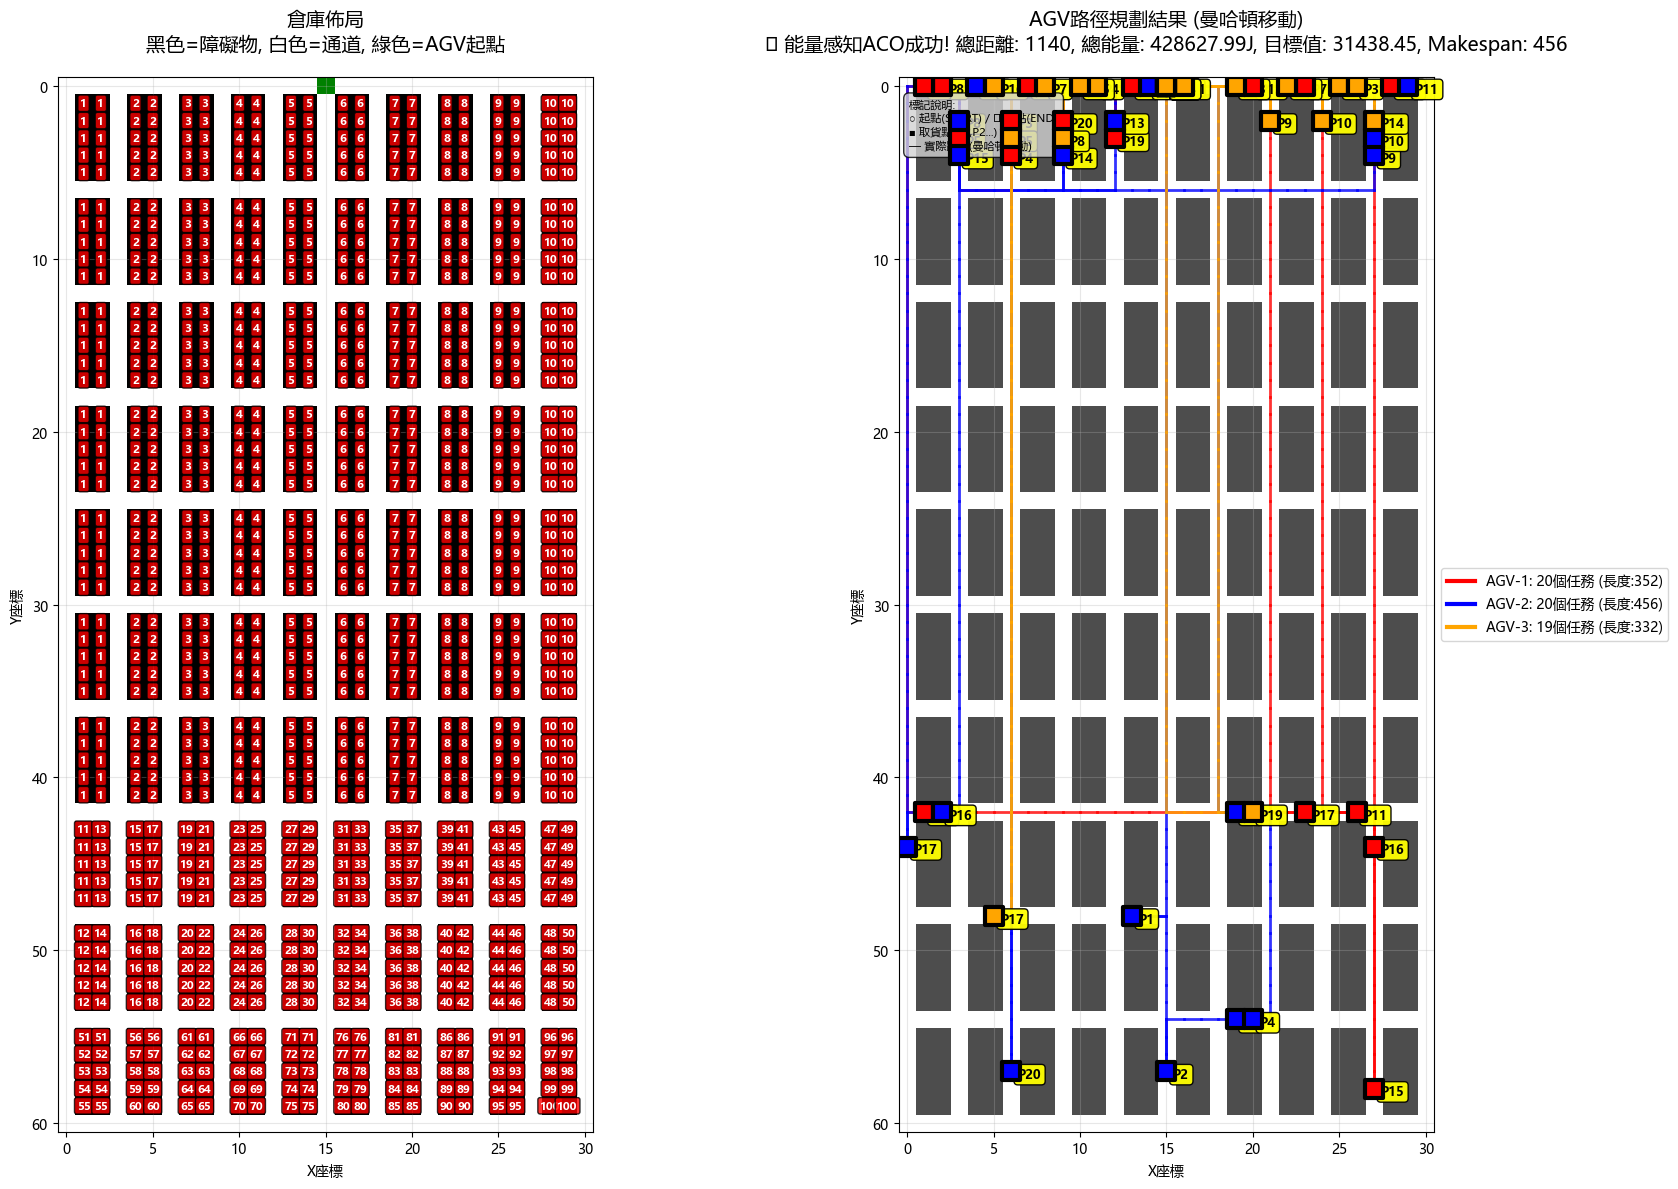

🎨 創建分批執行視覺化 (重新設計版)...
   🔍 AGV-1 有分批執行，創建分批圖表...
      📍 完整waypoints: [(15, 0), (13, 0), (7, 0), (6, 2), (6, 4), (3, 3), (15, 0), (23, 0), (2, 0), (1, 0), (1, 42), (26, 42), (15, 0), (20, 0), (28, 0), (27, 58), (27, 44), (23, 42), (15, 0), (12, 3), (9, 2), (15, 0)]
      🏠 Depot出現位置: [0, 6, 12, 18, 21]
      📏 完整路徑長度: 353
      📦 批次 1 waypoints: [(15, 0), (13, 0), (7, 0), (6, 2), (6, 4), (3, 3), (15, 0)]
      📦 批次 2 waypoints: [(15, 0), (23, 0), (2, 0), (1, 0), (1, 42), (26, 42), (15, 0)]
      📦 批次 3 waypoints: [(15, 0), (20, 0), (28, 0), (27, 58), (27, 44), (23, 42), (15, 0)]
      📦 批次 4 waypoints: [(15, 0), (12, 3), (9, 2), (15, 0)]
         🔄 重新規劃批次 1 路徑...
            📍 規劃段落: (15, 0) -> (13, 0)
            ✅ 段落規劃成功: 3 個點
            📍 規劃段落: (13, 0) -> (7, 0)
            ✅ 段落規劃成功: 7 個點
            📍 規劃段落: (7, 0) -> (6, 2)
            ✅ 段落規劃成功: 4 個點
            📍 規劃段落: (6, 2) -> (6, 4)
            ✅ 段落規劃成功: 3 個點
            📍 規劃段落: (6, 4) -> (3, 3)
            ✅ 段落規劃成功: 9 個點
    

C:\Users\user\AppData\Local\Temp\ipykernel_14960\4258720542.py:173: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14960\4258720542.py:173: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14960\4258720542.py:177: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
C:\Users\user\AppData\Local\Temp\ipykernel_14960\4258720542.py:177: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Microsoft YaHei.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


      ✅ AGV-1 分批圖表已儲存: batch_aco_AGV-1_batches_fixed.png


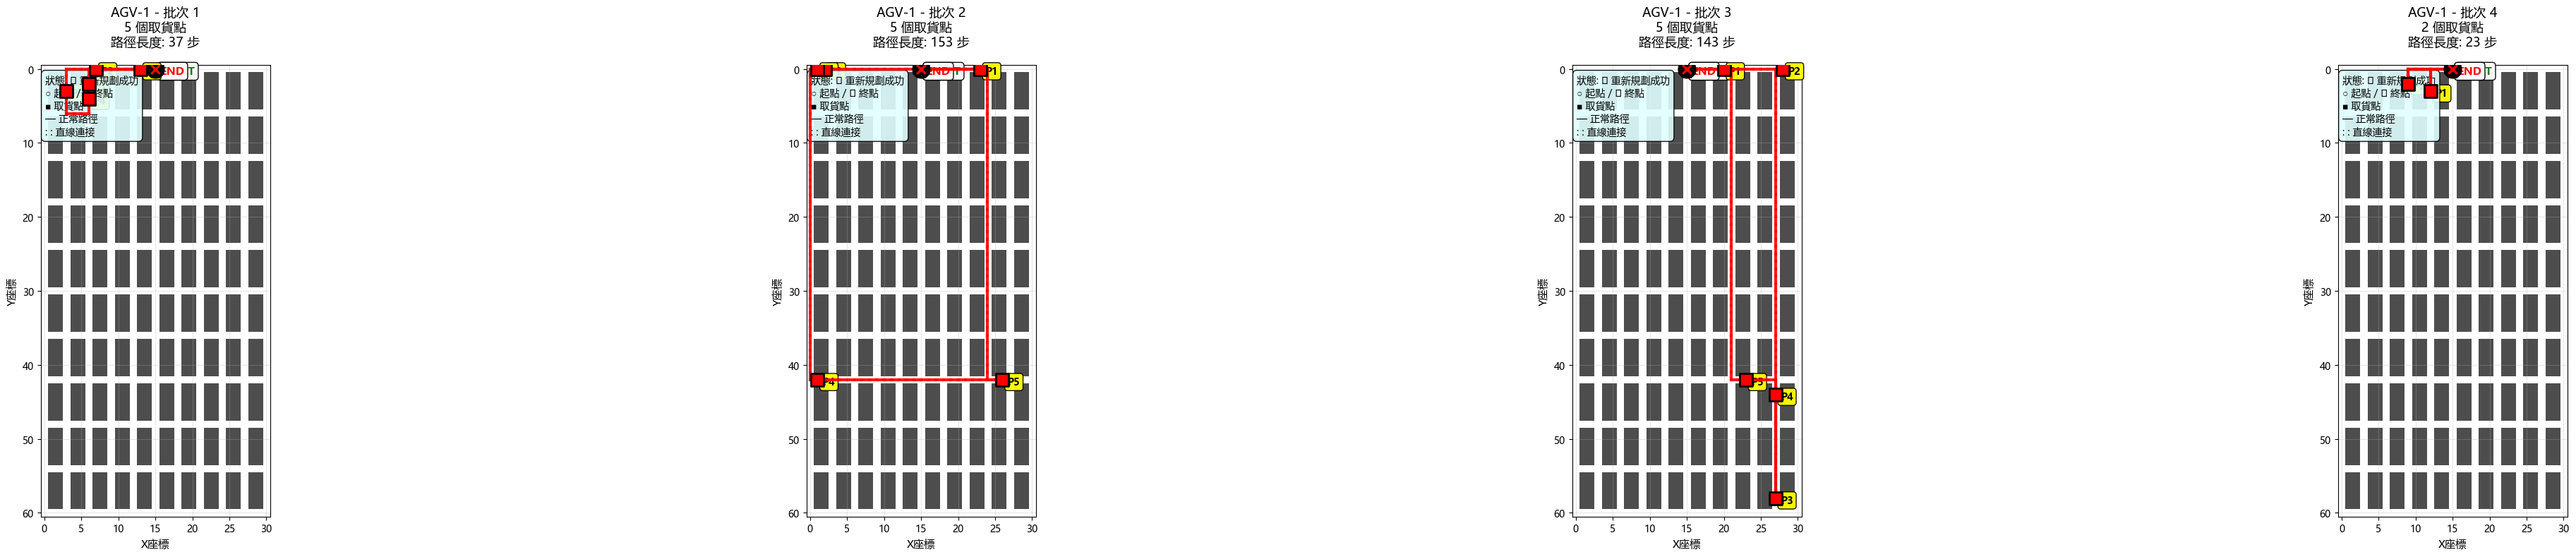

   🔍 AGV-2 有分批執行，創建分批圖表...
      📍 完整waypoints: [(15, 0), (13, 48), (15, 57), (19, 54), (20, 54), (19, 42), (15, 0), (14, 0), (3, 2), (27, 4), (27, 3), (29, 0), (15, 0), (12, 2), (9, 4), (3, 4), (2, 42), (0, 44), (15, 0), (4, 0), (6, 57), (15, 0)]
      🏠 Depot出現位置: [0, 6, 12, 18, 21]
      📏 完整路徑長度: 457
      📦 批次 1 waypoints: [(15, 0), (13, 48), (15, 57), (19, 54), (20, 54), (19, 42), (15, 0)]
      📦 批次 2 waypoints: [(15, 0), (14, 0), (3, 2), (27, 4), (27, 3), (29, 0), (15, 0)]
      📦 批次 3 waypoints: [(15, 0), (12, 2), (9, 4), (3, 4), (2, 42), (0, 44), (15, 0)]
      📦 批次 4 waypoints: [(15, 0), (4, 0), (6, 57), (15, 0)]
         🔄 重新規劃批次 1 路徑...
            📍 規劃段落: (15, 0) -> (13, 48)
            ✅ 段落規劃成功: 51 個點
            📍 規劃段落: (13, 48) -> (15, 57)
            ✅ 段落規劃成功: 12 個點
            📍 規劃段落: (15, 57) -> (19, 54)
            ✅ 段落規劃成功: 8 個點
            📍 規劃段落: (19, 54) -> (20, 54)
            ✅ 段落規劃成功: 2 個點
            📍 規劃段落: (20, 54) -> (19, 42)
            ✅ 段落規劃成功: 16 個點


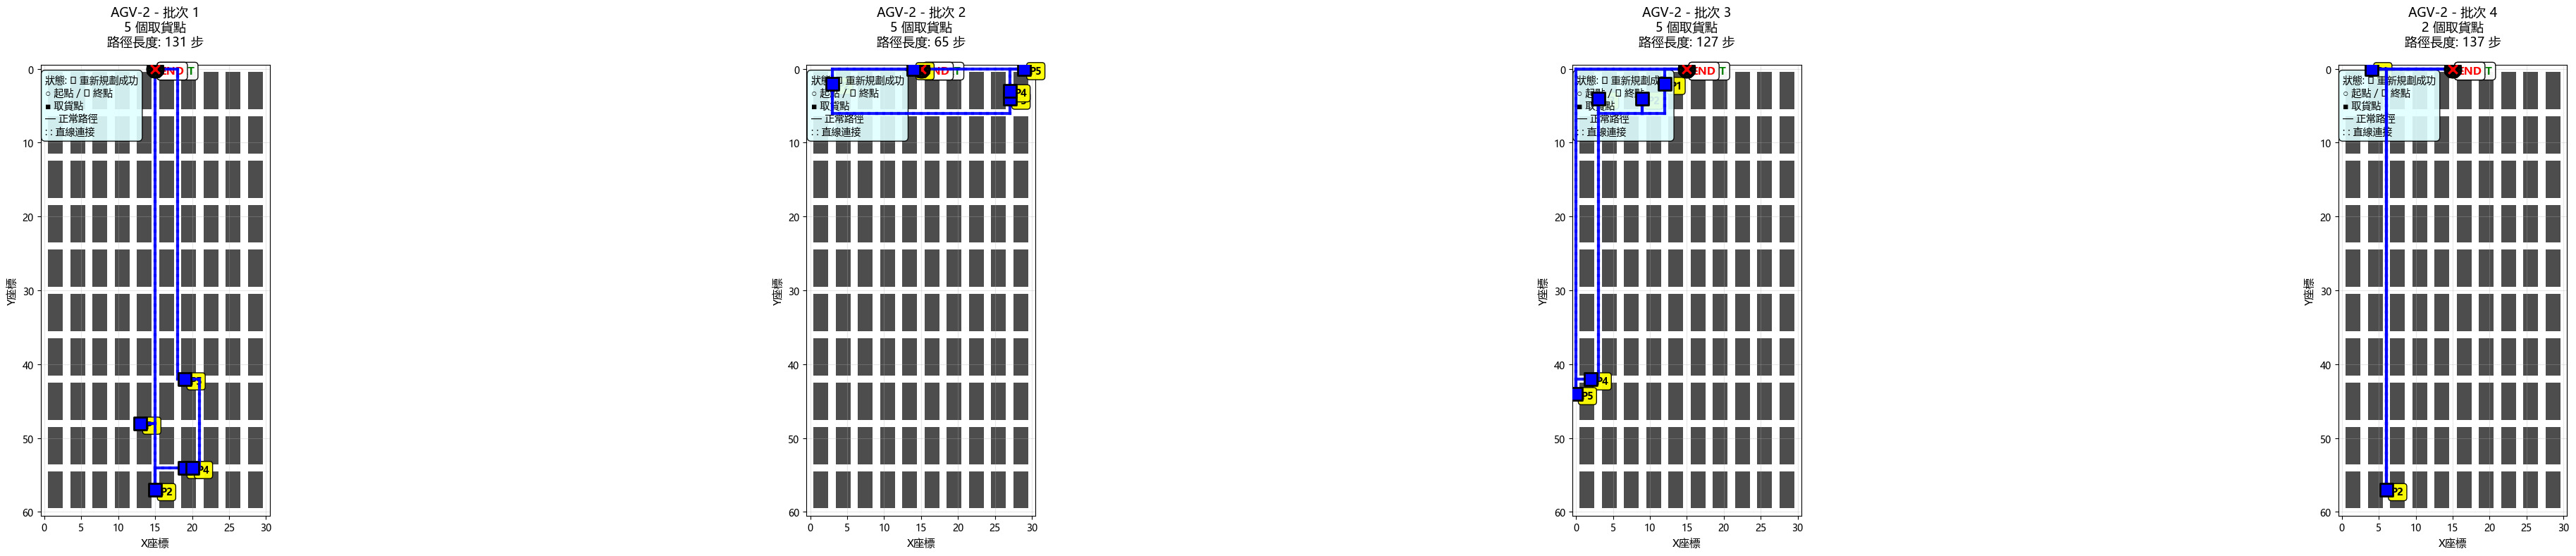

   🔍 AGV-3 有分批執行，創建分批圖表...
      📍 完整waypoints: [(15, 0), (16, 0), (25, 0), (26, 0), (11, 0), (6, 3), (15, 0), (8, 0), (9, 3), (21, 2), (24, 2), (22, 0), (15, 0), (19, 0), (27, 2), (10, 0), (5, 0), (5, 48), (15, 0), (20, 42), (15, 0)]
      🏠 Depot出現位置: [0, 6, 12, 18, 20]
      📏 完整路徑長度: 333
      📦 批次 1 waypoints: [(15, 0), (16, 0), (25, 0), (26, 0), (11, 0), (6, 3), (15, 0)]
      📦 批次 2 waypoints: [(15, 0), (8, 0), (9, 3), (21, 2), (24, 2), (22, 0), (15, 0)]
      📦 批次 3 waypoints: [(15, 0), (19, 0), (27, 2), (10, 0), (5, 0), (5, 48), (15, 0)]
      📦 批次 4 waypoints: [(15, 0), (20, 42), (15, 0)]
         🔄 重新規劃批次 1 路徑...
            📍 規劃段落: (15, 0) -> (16, 0)
            ✅ 段落規劃成功: 2 個點
            📍 規劃段落: (16, 0) -> (25, 0)
            ✅ 段落規劃成功: 10 個點
            📍 規劃段落: (25, 0) -> (26, 0)
            ✅ 段落規劃成功: 2 個點
            📍 規劃段落: (26, 0) -> (11, 0)
            ✅ 段落規劃成功: 16 個點
            📍 規劃段落: (11, 0) -> (6, 3)
            ✅ 段落規劃成功: 9 個點
            📍 規劃段落: (6, 3) -> (15, 0)

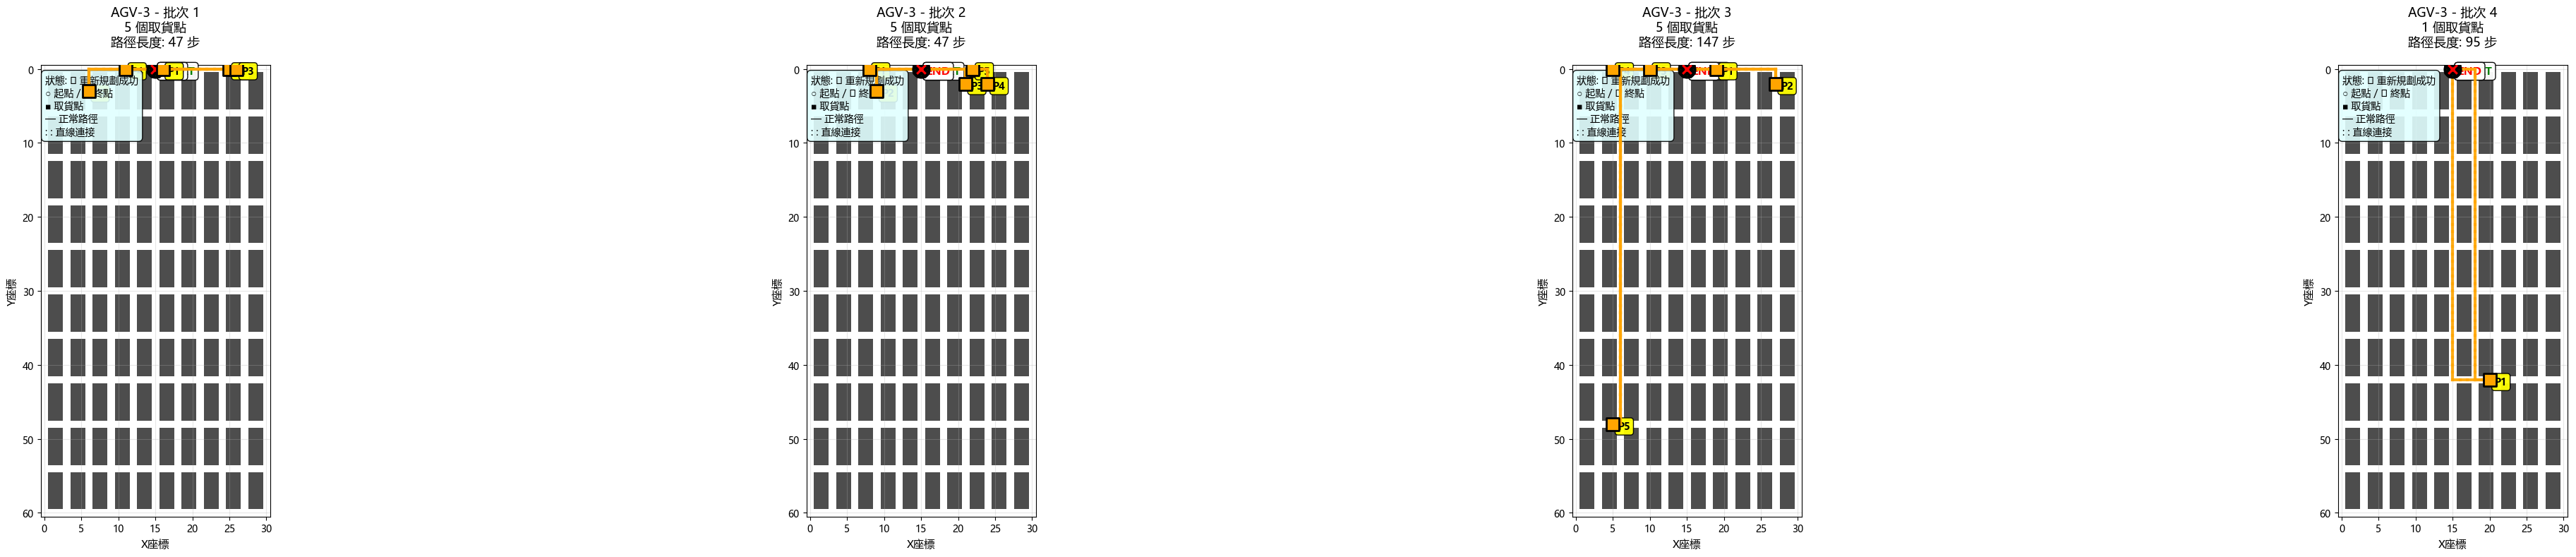


📤 匯出結果...
📤 正在匯出路徑到 routes_aco_for_flexsim.csv...
✅ 成功匯出 1196 筆路徑資料到 routes_aco_for_flexsim.csv

📋 匯出資料預覽:
AGV_ID                                                                                                                          Order  Step  X  Y        Action
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5,Task-6,Task-7,Task-8,Task-9,Task-10,Task-11,Task-12,Task-13,Task-14,Task-15,Task-16,Task-17   1.0 15  0          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5,Task-6,Task-7,Task-8,Task-9,Task-10,Task-11,Task-12,Task-13,Task-14,Task-15,Task-16,Task-17   1.5 15  0 PICKUP_Item-6
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5,Task-6,Task-7,Task-8,Task-9,Task-10,Task-11,Task-12,Task-13,Task-14,Task-15,Task-16,Task-17   2.0 14  0          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5,Task-6,Task-7,Task-8,Task-9,Task-10,Task-11,Task-12,Task-13,Task-14,Task-15,Task-16,Task-17   3.0 13  0          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5,Task-6,Task-7,Task-8,Task-9,Task-10,Task-11,Task-1

In [83]:
def visualize_batch_execution_fixed(warehouse: Warehouse, route_results: Dict, 
                                   save_prefix="batch", figsize=(12, 8)):
    """
    完全重新設計的分批視覺化函數 - 解決路徑提取問題
    """
    print(f"🎨 創建分批執行視覺化 (重新設計版)...")
    
    colors_agv = ['red', 'blue', 'orange', 'purple', 'brown', 'pink', 'cyan', 'yellow']
    
    for agv_idx, (agv_name, path) in enumerate(route_results['agv_paths'].items()):
        if not path or len(path) <= 1:
            continue
            
        color = colors_agv[agv_idx % len(colors_agv)]
        waypoints = route_results['agv_waypoints'][agv_name]
        
        # 檢查是否有分批（waypoints中有多個depot出現）
        depot = (15, 0)
        depot_indices = [i for i, wp in enumerate(waypoints) if wp == depot]
        
        if len(depot_indices) > 2:  # 起點、中間返回點、終點
            print(f"   🔍 {agv_name} 有分批執行，創建分批圖表...")
            print(f"      📍 完整waypoints: {waypoints}")
            print(f"      🏠 Depot出現位置: {depot_indices}")
            print(f"      📏 完整路徑長度: {len(path)}")
            
            # 🔧 新方法：直接重新規劃每個批次的路徑
            batches = []
            for i in range(len(depot_indices) - 1):
                start_idx = depot_indices[i]
                end_idx = depot_indices[i + 1]
                batch_waypoints = waypoints[start_idx:end_idx + 1]
                batches.append(batch_waypoints)
                print(f"      📦 批次 {i+1} waypoints: {batch_waypoints}")
            
            # 為每個批次創建圖表
            fig, axes = plt.subplots(1, len(batches), figsize=(figsize[0] * len(batches), figsize[1]))
            if len(batches) == 1:
                axes = [axes]
            
            for batch_idx, (ax, batch_waypoints) in enumerate(zip(axes, batches)):
                # 背景倉庫佈局
                display_grid = warehouse.map_mask.copy().astype(float)
                display_grid[0, 15] = 2  # 標記depot
                
                colors = ['black', 'white', 'green']
                cmap = ListedColormap(colors)
                
                im = ax.imshow(display_grid, cmap=cmap, vmin=0, vmax=2, alpha=0.7)
                
                # 🔧 新方法：重新規劃此批次的路徑
                print(f"         🔄 重新規劃批次 {batch_idx+1} 路徑...")
                
                batch_path = []
                path_valid = True
                
                # 逐段規劃路徑
                for wp_idx in range(len(batch_waypoints) - 1):
                    start_point = batch_waypoints[wp_idx]
                    end_point = batch_waypoints[wp_idx + 1]
                    
                    print(f"            📍 規劃段落: {start_point} -> {end_point}")
                    
                    # 使用BFS重新規劃這一段路徑
                    segment_path = warehouse.bfs_path(start_point, end_point)
                    
                    if segment_path is None:
                        print(f"            ❌ 段落規劃失敗: {start_point} -> {end_point}")
                        path_valid = False
                        break
                    
                    # 合併路徑段落
                    if len(batch_path) == 0:
                        batch_path.extend(segment_path)
                    else:
                        batch_path.extend(segment_path[1:])  # 避免重複點
                    
                    print(f"            ✅ 段落規劃成功: {len(segment_path)} 個點")
                
                print(f"         📊 批次路徑總長度: {len(batch_path)} 個點")
                
                # 繪製重新規劃的路徑
                if path_valid and len(batch_path) > 1:
                    print(f"         🎨 繪製批次 {batch_idx + 1} 重新規劃路徑...")
                    
                    # 驗證並繪製每一步
                    valid_steps = 0
                    invalid_steps = 0
                    
                    for step_idx in range(len(batch_path) - 1):
                        current = batch_path[step_idx]
                        next_point = batch_path[step_idx + 1]
                        
                        # 檢查曼哈頓移動
                        dx = abs(next_point[0] - current[0])
                        dy = abs(next_point[1] - current[1])
                        
                        if (dx == 1 and dy == 0) or (dx == 0 and dy == 1):
                            # 正確的曼哈頓移動
                            ax.plot([current[0], next_point[0]], [current[1], next_point[1]], 
                                   color=color, linewidth=3, alpha=0.9, zorder=5)
                            valid_steps += 1
                        else:
                            print(f"            ⚠️  重新規劃後仍有問題: {current} -> {next_point}")
                            # 用橙色虛線標示
                            ax.plot([current[0], next_point[0]], [current[1], next_point[1]], 
                                   color='orange', linewidth=2, alpha=0.7, linestyle='--', zorder=4)
                            invalid_steps += 1
                    
                    print(f"            ✅ 有效步驟: {valid_steps}, ⚠️  問題步驟: {invalid_steps}")
                    
                else:
                    print(f"         🔧 路徑規劃失敗，使用直線連接...")
                    # 備用方案：直線連接waypoints
                    for j in range(len(batch_waypoints) - 1):
                        start = batch_waypoints[j]
                        end = batch_waypoints[j + 1]
                        ax.plot([start[0], end[0]], [start[1], end[1]], 
                               color=color, linewidth=3, alpha=0.5, linestyle=':', zorder=3)
                        
                        # 標示為直線連接
                        mid_x = (start[0] + end[0]) / 2
                        mid_y = (start[1] + end[1]) / 2
                        ax.text(mid_x, mid_y, 'DIRECT', fontsize=8, ha='center', va='center',
                               bbox=dict(boxstyle="round,pad=0.2", facecolor='orange', alpha=0.8))
                
                # 標記關鍵點
                if len(batch_waypoints) >= 2:
                    # 起點
                    start_point = batch_waypoints[0]
                    ax.scatter(start_point[0], start_point[1], c='green', s=250, 
                             marker='o', edgecolor='black', linewidth=3, zorder=10)
                    ax.text(start_point[0]+0.7, start_point[1]+0.7, 'START', 
                           fontsize=11, fontweight='bold', color='green',
                           bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.95))
                    
                    # 終點
                    end_point = batch_waypoints[-1]
                    ax.scatter(end_point[0], end_point[1], c='red', s=220, 
                             marker='X', edgecolor='black', linewidth=3, zorder=10)
                    ax.text(end_point[0]+0.7, end_point[1]+0.7, 'END', 
                           fontsize=11, fontweight='bold', color='red',
                           bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.95))
                    
                    # 取貨點
                    pickup_points = batch_waypoints[1:-1]
                    for j, point in enumerate(pickup_points):
                        ax.scatter(point[0], point[1], c=color, s=180, 
                                 marker='s', edgecolor='black', linewidth=2, zorder=11)
                        ax.text(point[0]+0.7, point[1]+0.7, f'P{j+1}', 
                               fontsize=10, fontweight='bold', color='black',
                               bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.95))
                
                # 設定圖表
                pickup_count = len(batch_waypoints) - 2
                path_len = len(batch_path) if batch_path else 0
                
                ax.set_title(f'{agv_name} - 批次 {batch_idx + 1}\n'
                           f'{pickup_count} 個取貨點\n'
                           f'路徑長度: {path_len} 步', 
                           fontsize=13, pad=20)
                ax.grid(True, alpha=0.3)
                ax.set_xlabel('X座標', fontsize=11)
                ax.set_ylabel('Y座標', fontsize=11)
                
                # 添加詳細圖例
                status = "✅ 重新規劃成功" if path_valid else "⚠️ 使用直線連接"
                legend_text = f"狀態: {status}\n○ 起點 / ✕ 終點\n■ 取貨點\n— 正常路徑\n: : 直線連接"
                ax.text(0.02, 0.98, legend_text, transform=ax.transAxes, 
                       fontsize=10, verticalalignment='top',
                       bbox=dict(boxstyle="round,pad=0.4", facecolor='lightcyan', alpha=0.9))
            
            plt.tight_layout()
            
            # 儲存圖表
            save_path = f"{save_prefix}_{agv_name}_batches_fixed.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"      ✅ {agv_name} 分批圖表已儲存: {save_path}")
            plt.show()
        
        else:
            print(f"   ℹ️  {agv_name} 無分批執行，跳過...")

print("🔧 全新分批視覺化系統已完成")

# 替換原來的函數
visualize_batch_execution = visualize_batch_execution_fixed
print("✅ 已替換為修復版本，請重新運行您的演示代碼")
def print_route_summary(results: Dict):
    """
    輸出路徑規劃結果摘要
    """
    print(f"\n📊 路徑規劃結果摘要")
    print("="*50)
    
    if results['success']:
        print(f"✅ 規劃成功!")
        print(f"   📏 總路徑距離: {results['total_distance']}")
        if 'aco_makespan' in results:
            print(f"   ⏱️  ACO Makespan: {results['aco_makespan']:.2f}")
        
        print(f"\n🚛 各AGV詳細資訊:")
        for agv_name, path in results['agv_paths'].items():
            path_length = len(path) - 1 if path else 0
            waypoints = results['agv_waypoints'].get(agv_name, [])
            pickup_count = max(0, len(waypoints) - 2)  # 排除起點終點
            
            print(f"   {agv_name}:")
            print(f"      📦 取貨點數: {pickup_count}")
            print(f"      📏 路徑長度: {path_length}")
            print(f"      🎯 關鍵點: {waypoints}")
    else:
        print(f"❌ 規劃失敗: {results['message']}")
        print(f"   違規數量: {results['violations']}")

print("🔧 分批視覺化系統已修復完成")
def run_complete_agv_demo(csv_file='warehouse.csv', depot=(15, 0), 
                         all_task_items=None, orders=None, num_agvs=3,
                         use_aco_allocation=True, visualize=True, export=True) -> tuple:
    """
    完整的AGV路徑規劃演示函數
    
    參數:
    - csv_file: 倉庫佈局CSV檔案
    - depot: AGV起始位置
    - all_task_items: 所有任務項目列表（ACO分配模式）
    - orders: 預設訂單列表（固定分配模式）
    - num_agvs: AGV數量
    - use_aco_allocation: 是否使用ACO動態分配
    - visualize: 是否顯示視覺化
    - export: 是否匯出結果
    
    返回:
    - (warehouse, results): 倉庫物件和結果字典
    """
    print(f"🚀 啟動AGV路徑規劃演示系統...")
    print(f"   📂 倉庫檔案: {csv_file}")
    print(f"   🏠 AGV起點: {depot}")
    print(f"   🚛 AGV數量: {num_agvs}")
    print(f"   🎯 分配方式: {'ACO動態分配' if use_aco_allocation else '固定分配'}")
    
    try:
        # 1. 載入倉庫
        warehouse = load_warehouse_from_csv(csv_file)
        print(f"✅ 倉庫載入成功")
        
        # 2. 根據分配方式規劃路徑
        if use_aco_allocation:
            if all_task_items is None:
                raise ValueError("使用ACO分配時必須提供 all_task_items 參數")
            
            print(f"🎯 使用ACO動態分配 {len(all_task_items)} 個任務...")
            results = plan_agv_routes_with_energy_aco(
                warehouse=warehouse,
                all_task_items=all_task_items,
                num_agvs=num_agvs,
                depot=depot,
                max_items_per_trip=5,
                gamma=0.5, 
                delta=0.5
            )
        else:
            if orders is None:
                raise ValueError("使用固定分配時必須提供 orders 參數")
        
        # 3. 輸出結果摘要
        print_route_summary(results)
        
        # 4. 視覺化（可選）
        if visualize and results['success']:
            print(f"\n🎨 創建視覺化圖表...")
            visualize_warehouse_with_routes(
                warehouse, results, 
                figsize=(20, 12), 
                save_path=f"agv_routes_{'aco' if use_aco_allocation else 'fixed'}.png"
            )
            
            # 分批執行視覺化（如果有多批任務）
            visualize_batch_execution(
                warehouse, results,
                save_prefix=f"batch_{'aco' if use_aco_allocation else 'fixed'}"
            )
        
        # 5. 匯出結果（可選）
        if export and results['success']:
            print(f"\n📤 匯出結果...")
            export_routes_to_flexsim(
                results, warehouse,
                output_file=f"routes_{'aco' if use_aco_allocation else 'fixed'}_for_flexsim.csv"
            )
            export_warehouse_layout(
                warehouse,
                output_file="warehouse_layout_for_flexsim.csv"
            )
        
        return warehouse, results
        
    except Exception as e:
        print(f"❌ 演示執行失敗: {str(e)}")
        return None, {'success': False, 'message': f"執行失敗: {str(e)}"}

print("🚀 完整AGV演示函數定義完成")
# 🎯 自訂任務輸入 - ACO動態分配演示系統
print("🎯 自訂任務輸入 - ACO動態分配演示系統")
print("="*60)

# ✏️ 🎯 在這裡直接指定您要的任務項目 - 修改下面這行即可
custom_task_items = ['18', '3', '10', '6', '2', '3', '1', '37', '2', '28', '41', '11', '3', '99', '7', '1', '13', '7', '10', '73', '4', '9', '5', '9', '2', '1', '9', '1', '2', '10', '4', '8', '3', '10', '8', '5', '35', '45', '4', '3', '2', '58', '10', '4', '1', '81', '11', '45', '8', '81']  # 🎯 您可以修改這裡

print(f"📝 自訂任務項目: {custom_task_items}")
print(f"📊 總共 {len(custom_task_items)} 個任務")
print(f"💡 任務範圍: 最小={min(custom_task_items, key=lambda x: int(x))}, 最大={max(custom_task_items, key=lambda x: int(x))}")

# 執行ACO任務分配
print(f"\n🤖 使用3台AGV分配 {len(custom_task_items)} 個自訂任務")
print("⚠️  注意：每台AGV執行5個任務後必須返回起點(15,0)")

try:
    warehouse, results = run_complete_agv_demo(
        csv_file='warehouse.csv',
        depot=(15, 0),  # AGV起始位置 (15,0)
        all_task_items=custom_task_items,  # 🎯 使用自訂任務
        num_agvs=3,      # AGV數量
        use_aco_allocation=True,  # 使用ACO動態分配
        visualize=True,   # 顯示視覺化
        export=True,      # 匯出結果
    )

    # 🎯 添加這段詳細結果展示
    if results and results['success']:
        print("\n" + "🎯 ACO動態分配系統執行結果")
        print("="*60)
        print(f"✅ 成功分配並規劃 {len(custom_task_items)} 個任務:")
        print(f"   - 任務內容: {custom_task_items}")
        print(f"   - 總路徑距離: {results['total_distance']}")
        print(f"   - 總能量消耗: {results['total_energy']:.2f} J")  # 🔋 修復
        print(f"   - ACO Makespan: {results['aco_makespan']:.2f}")  # 🔋 修復
        print(f"   - 多目標值: {results['multi_objective_value']:.2f}")
        print(f"   - 能量配置: {results['energy_config']}")
        print(f"   - 每5個任務返回起點(15,0)規則: ✅ 已啟用")
        
        # 🔋 顯示詳細能量分析
        if 'agv_energy_details' in results:
            print(f"\n🔋 詳細能量分析:")
            total_breakdown = {'E_roll_J': 0, 'E_accel_J': 0, 'E_rot_J': 0, 'E_lift_J': 0, 'E_idle_J': 0}
            
            for agv_name, energy_detail in results['agv_energy_details'].items():
                print(f"   {agv_name}: {energy_detail['E_total_J']:.2f}J")
                print(f"      └ 滾動:{energy_detail['E_roll_J']:.1f} + 加速:{energy_detail['E_accel_J']:.1f} + 轉向:{energy_detail['E_rot_J']:.1f} + 升降:{energy_detail['E_lift_J']:.1f} + 待機:{energy_detail['E_idle_J']:.1f}")
                
                for key in total_breakdown:
                    total_breakdown[key] += energy_detail[key]
            
            print(f"   📊 總計能量分解:")
            print(f"      🎯 滾動阻力: {total_breakdown['E_roll_J']:.1f}J ({total_breakdown['E_roll_J']/results['total_energy']*100:.1f}%)")
            print(f"      🚀 加速能量: {total_breakdown['E_accel_J']:.1f}J ({total_breakdown['E_accel_J']/results['total_energy']*100:.1f}%)")
            print(f"      🔄 轉向能量: {total_breakdown['E_rot_J']:.1f}J ({total_breakdown['E_rot_J']/results['total_energy']*100:.1f}%)")
            print(f"      📦 升降能量: {total_breakdown['E_lift_J']:.1f}J ({total_breakdown['E_lift_J']/results['total_energy']*100:.1f}%)")
            print(f"      ⏱️ 待機能量: {total_breakdown['E_idle_J']:.1f}J ({total_breakdown['E_idle_J']/results['total_energy']*100:.1f}%)")
        
        # 🔋 批次分析
        print(f"\n📦 批次執行分析:")
        for agv_name, waypoints in results['agv_waypoints'].items():
            depot_count = waypoints.count((15, 0))  # 計算返回起點次數
            batch_count = depot_count - 1  # 減去最終返回
            pickup_count = len(waypoints) - 2  # 總取貨點數
            
            if batch_count > 0:
                print(f"   {agv_name}: {pickup_count}個任務 → {batch_count+1}批次執行 (每批≤5個)")
                
                # 分析每批任務數
                depot_indices = [i for i, wp in enumerate(waypoints) if wp == (15, 0)]
                for i in range(len(depot_indices) - 1):
                    start_idx = depot_indices[i]
                    end_idx = depot_indices[i + 1]
                    batch_tasks = end_idx - start_idx - 1
                    print(f"      📦 批次{i+1}: {batch_tasks}個任務")
            else:
                print(f"   {agv_name}: {pickup_count}個任務 → 單批次執行")
        
        # 顯示分配結果
        if 'task_allocation' in results:
            print(f"\n📊 ACO最佳分配結果:")
            for agv_name, alloc_info in results['task_allocation'].items():
                print(f"   {agv_name}: {alloc_info['num_tasks']} 個任務")
        
        print("\n💡 能量感知ACO系統優勢:")
        print("   ✅ 多目標優化：平衡能量消耗與路徑效率")
        print("   ✅ 全域最佳化分配，避免位置衝突")  
        print("   ✅ 動態負載平衡，確保工作均勻分配")
        print("   ✅ 支援批次執行，每5個任務返回起點")
        print("   ✅ 詳細能量分析，支援節能策略調整")
        print("="*60)
    else:
        print("\n❌ ACO分配執行失敗")
        
except NameError as e:
    print("❌ 缺少必要的函數定義，請確保已運行所有前置Cell")
    print(f"   錯誤: {str(e)}")
    print("\n💡 解決方法:")
    print("   1. 確認已運行包含 run_complete_agv_demo 函數的Cell")
    print("   2. 確認已運行包含 load_warehouse_from_csv 函數的Cell")
    print("   3. 確認已運行所有必要的類別定義Cell")

except Exception as e:
    print(f"❌ 執行過程發生錯誤: {str(e)}")
    print("\n💡 可能的原因:")
    print("   - 倉庫檔案 'warehouse.csv' 或 'MapMask_preview.csv' 不存在")
    print("   - 指定的任務項目在倉庫中不存在")
    print("   - 系統資源不足")